## tl;dr

This is a **walk-forward replay**, not a hindsight chart review. It reruns the
production `crypto-quant-v2` rules at each UTC daily close using only candles
available at that moment, then scores the next 4, 12, and 24 daily candles.

- Universe: BTC/USDT, ETH/USDT, SOL/USDT.
- Evaluation dates: 2025-07-01 through 2026-07-04.
- Raw decision dates: 1,107 asset-days; exported scenario/horizon rows: 9,963.
- Confirmed directional signals: 79 (42 bullish, 37 bearish). Pooled terminal
  direction accuracy is **44.3%, 46.8%, and 49.4%** at 4/12/24 days. With a
  horizon-length cooldown to reduce overlapping samples it is **36.5%, 48.7%,
  and 51.6%** (n=52/39/31). This does **not** establish a stable directional edge.
- The bearish branch is materially better than the bullish branch in this
  particular period; the bullish branch is below its unconditional up-market
  baseline at every horizon. That asymmetry must not be hidden by pooling.
- Confirmed range signals have 4-day endpoint accuracy **73.7%** and strict
  whole-path accuracy **64.3%**. By 24 days these fall to **48.2%** and **10.7%**.
  The tool is more credible as a short-range state classifier than as a
  medium-horizon direction predictor.
- “Target before invalidation” is around 80% while terminal direction is below
  50%. Reporting only target-touch metrics would therefore be misleading.

Conclusion: the current tool is useful for transparent conditional scenarios
and short-range monitoring, but its confirmed directional labels are not yet
accurate enough to present as a quantitatively validated forecast.

## Context & Methods

The replay imports the current production `buildQuantAnalysis` implementation
instead of rebuilding formulas in Python. At every decision timestamp it:

1. supplies up to the same 500 historical candles per 1h/4h/1d/1w timeframe;
2. lets the production module separate forming from closed candles;
3. records trigger, confirmation, K-line-only support verdict, target, and
   invalidation;
4. reveals later daily candles only after the decision is recorded.

Directional scenarios are scored by the sign of the horizon-end close return.
Range scenarios are scored three ways: horizon-end close in the predicted
range, every intervening close in the predicted range, and every intervening
close inside the wider invalidation band.

The 95% confidence intervals are Wilson intervals. Daily signals overlap, so a
second view enforces a horizon-length cooldown per asset and scenario. This is
not a portfolio backtest: no position sizing, slippage model, funding, or
execution engine is assumed.

In [1]:
from pathlib import Path
import gzip
import hashlib
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
records_path = ROOT / "backtest-records.csv"
metadata_path = ROOT / "metadata.json"
raw_path = ROOT / "raw-candles.json.gz"

df = pd.read_csv(records_path)
metadata = json.loads(metadata_path.read_text())
for column in [
    "trigger_met", "confirmed", "direction_correct", "invalidated",
    "direction_correct_after_10bps", "target_hit",
    "target_before_invalidation",
    "range_final_inside", "range_strict_path_inside",
    "range_relaxed_path_inside",
]:
    if column in df:
        df[column] = df[column].map(
            {"true": True, "false": False, True: True, False: False}
        ).astype("boolean")

df["signal_date"] = pd.to_datetime(df["signal_date"], utc=True)
print({
    "rows": len(df),
    "assets": sorted(df.asset.unique()),
    "first_signal": str(df.signal_date.min().date()),
    "last_signal": str(df.signal_date.max().date()),
    "formula_version": metadata["formulaVersion"],
    "raw_sha256": metadata["rawDataSha256"],
    "records_sha256": metadata["recordsSha256"],
})

{'rows': 9963, 'assets': ['BTC', 'ETH', 'SOL'], 'first_signal': '2025-07-01', 'last_signal': '2026-07-04', 'formula_version': 'crypto-quant-v2', 'raw_sha256': 'a306e910e49a71cb3239c955147ae19dee59a9caed0ba68a12f2ec7f0c883902', 'records_sha256': 'aa794816f8b5bd54a7bab092c34ca165c9cf0d5a592144b114d85899cc39d381'}


## Data

Gate public spot OHLCV is the sole market-data source. The saved gzip snapshot,
CSV, production-code hashes, formula version, and evaluation timestamps make
every score reproducible. Gate limits 1-hour history to roughly 10,000 candles,
which sets the honest evaluation start; no other exchange was spliced in.

In [2]:
raw_bytes = gzip.decompress(raw_path.read_bytes())
raw = json.loads(raw_bytes)
raw_sha = hashlib.sha256(raw_bytes).hexdigest()
csv_sha = hashlib.sha256(records_path.read_bytes()).hexdigest()

quality_rows = []
for asset, timeframes in raw.items():
    for timeframe, rows in timeframes.items():
        timestamps = [int(row["ts"]) for row in rows]
        numeric_ok = all(
            all(np.isfinite(float(row[field])) for field in ["open", "high", "low", "close", "volume"])
            for row in rows
        )
        ohlc_ok = all(
            float(row["high"]) >= max(float(row["open"]), float(row["close"]), float(row["low"]))
            and float(row["low"]) <= min(float(row["open"]), float(row["close"]), float(row["high"]))
            for row in rows
        )
        quality_rows.append({
            "asset": asset,
            "timeframe": timeframe,
            "rows": len(rows),
            "strictly_increasing": all(b > a for a, b in zip(timestamps, timestamps[1:])),
            "duplicate_timestamps": len(timestamps) - len(set(timestamps)),
            "numeric_ok": numeric_ok,
            "ohlc_consistent": ohlc_ok,
        })

quality = pd.DataFrame(quality_rows)
checks = {
    "raw_sha_matches_metadata": raw_sha == metadata["rawDataSha256"],
    "csv_sha_matches_metadata": csv_sha == metadata["recordsSha256"],
    "unique_asset_date_scenario_horizon": not df.duplicated(
        ["asset", "signal_date", "scenario_id", "horizon"]
    ).any(),
    "future_starts_after_decision": bool(
        (df.outcome_start_timestamp_ms >= df.decision_timestamp_ms).all()
    ),
    "future_ends_after_start": bool(
        (df.outcome_end_timestamp_ms >= df.outcome_start_timestamp_ms).all()
    ),
    "no_missing_future_close": not df.final_close.isna().any(),
    "all_raw_series_monotonic": bool(quality.strictly_increasing.all()),
    "no_raw_timestamp_duplicates": bool((quality.duplicate_timestamps == 0).all()),
    "raw_numeric_values_valid": bool(quality.numeric_ok.all()),
    "raw_ohlc_consistent": bool(quality.ohlc_consistent.all()),
}
display(quality)
display(pd.Series(checks, name="passed").to_frame())
assert all(checks.values()), checks

,asset,timeframe,rows,strictly_increasing,duplicate_timestamps,numeric_ok,ohlc_consistent
0,BTC,1h,9961,True,0,True,True
1,BTC,4h,4171,True,0,True,True
2,BTC,1d,1215,True,0,True,True
3,BTC,1w,552,True,0,True,True
4,ETH,1h,9961,True,0,True,True
5,ETH,4h,4171,True,0,True,True
6,ETH,1d,1215,True,0,True,True
7,ETH,1w,543,True,0,True,True
8,SOL,1h,9961,True,0,True,True
9,SOL,4h,4171,True,0,True,True


,passed
raw_sha_matches_metadata,True
csv_sha_matches_metadata,True
unique_asset_date_scenario_horizon,True
future_starts_after_decision,True
future_ends_after_start,True
no_missing_future_close,True
all_raw_series_monotonic,True
no_raw_timestamp_duplicates,True
raw_numeric_values_valid,True
raw_ohlc_consistent,True


In [3]:
def wilson(values):
    values = pd.Series(values).dropna().astype(bool)
    n = len(values)
    if n == 0:
        return {"n": 0, "accuracy": np.nan, "ci_low": np.nan, "ci_high": np.nan}
    p = float(values.mean())
    z = 1.96
    denominator = 1 + z * z / n
    center = (p + z * z / (2 * n)) / denominator
    half = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / denominator
    return {"n": n, "accuracy": p, "ci_low": center - half, "ci_high": center + half}


def summarize(group, outcome):
    stats = wilson(group[outcome])
    if "signed_return" in group:
        stats["mean_signed_return"] = group.signed_return.mean()
        stats["median_signed_return"] = group.signed_return.median()
    return pd.Series(stats)


def cooldown(group, bars):
    kept = []
    last_timestamp = {}
    for index, row in group.sort_values("signal_timestamp_ms").iterrows():
        key = (row.asset, row.scenario_id)
        earliest = last_timestamp.get(key, -np.inf) + bars * 86_400_000
        if row.signal_timestamp_ms >= earliest:
            kept.append(index)
            last_timestamp[key] = row.signal_timestamp_ms
    return group.loc[kept]


def percent_table(frame, columns=("accuracy", "ci_low", "ci_high")):
    result = frame.copy()
    for column in columns:
        if column in result:
            result[column] = (
                100 * pd.to_numeric(result[column], errors="coerce")
            ).round(1)
    return result

## Results

### Confirmed directional scenarios

Accuracy below means the horizon-end close moved in the scenario direction.
The asset-weighted unconditional benchmark is the same direction’s historical
base rate over all eligible dates, not a fitted model.

In [4]:
confirmed_directional = df[df.confirmed & df.direction.ne("range")].copy()
direction_table = (
    confirmed_directional
    .groupby(["scenario_id", "horizon"], observed=True)
    .apply(lambda group: summarize(group, "direction_correct"), include_groups=False)
    .reset_index()
)

base = df[df.scenario_id.eq("bullish_breakout")].copy()
base_rates = (
    base.assign(up=base.raw_return.gt(0), down=base.raw_return.lt(0))
    .groupby(["asset", "horizon"], observed=True)[["up", "down"]]
    .mean()
)

benchmarks = []
for _, row in direction_table.iterrows():
    sample = confirmed_directional[
        confirmed_directional.scenario_id.eq(row.scenario_id)
        & confirmed_directional.horizon.eq(row.horizon)
    ]
    side = "up" if row.scenario_id == "bullish_breakout" else "down"
    benchmark = np.mean([
        base_rates.loc[(asset, int(row.horizon)), side]
        for asset in sample.asset
    ])
    benchmarks.append(benchmark)
direction_table["unconditional_benchmark"] = benchmarks
direction_table["accuracy_minus_benchmark"] = (
    direction_table.accuracy - direction_table.unconditional_benchmark
)
display(percent_table(direction_table, (
    "accuracy", "ci_low", "ci_high", "unconditional_benchmark",
    "accuracy_minus_benchmark",
)))

,scenario_id,horizon,n,accuracy,ci_low,ci_high,mean_signed_return,median_signed_return,unconditional_benchmark,accuracy_minus_benchmark
0,bearish_breakdown,4,37.0,51.4,35.9,66.6,0.017163,0.008833,50.8,0.5
1,bearish_breakdown,12,37.0,59.5,43.5,73.7,0.043303,0.039607,53.2,6.3
2,bearish_breakdown,24,37.0,73.0,57.0,84.6,0.087561,0.077592,57.8,15.2
3,bullish_breakout,4,42.0,38.1,25.0,53.2,-0.006312,-0.013613,49.0,-10.9
4,bullish_breakout,12,42.0,35.7,23.0,50.8,-0.015912,-0.025740,47.0,-11.2
5,bullish_breakout,24,42.0,28.6,17.2,43.6,-0.030279,-0.045035,42.7,-14.1


In [5]:
pooled_direction = (
    confirmed_directional
    .groupby("horizon", observed=True)
    .apply(lambda group: summarize(group, "direction_correct"), include_groups=False)
    .reset_index()
)
pooled_direction["target_before_invalidation"] = (
    confirmed_directional.groupby("horizon").target_before_invalidation.mean().values
)
pooled_direction["invalidated"] = (
    confirmed_directional.groupby("horizon").invalidated.mean().values
)
display(percent_table(pooled_direction, (
    "accuracy", "ci_low", "ci_high", "target_before_invalidation", "invalidated",
)))

,horizon,n,accuracy,ci_low,ci_high,mean_signed_return,median_signed_return,target_before_invalidation,invalidated
0,4,79.0,44.3,33.9,55.3,0.004683,-0.007265,79.7,15.2
1,12,79.0,46.8,36.2,57.7,0.011822,-0.016128,83.5,39.2
2,24,79.0,49.4,38.6,60.2,0.024912,-0.000699,83.5,50.6


The bearish branch improved with horizon in this sample, while the bullish
branch failed increasingly often. This is not a symmetric trend predictor.
The high target-touch rate cannot substitute for terminal-direction accuracy:
a scenario may briefly touch a nearby target and later reverse.

### Confirmed range scenarios

In [6]:
confirmed_range = df[df.confirmed & df.direction.eq("range")].copy()
range_rows = []
for horizon, group in confirmed_range.groupby("horizon", observed=True):
    for metric in [
        "range_final_inside",
        "range_strict_path_inside",
        "range_relaxed_path_inside",
    ]:
        range_rows.append({
            "horizon": horizon,
            "metric": metric,
            **wilson(group[metric]),
        })
range_table = pd.DataFrame(range_rows)
display(percent_table(range_table))

,horizon,metric,n,accuracy,ci_low,ci_high
0,4,range_final_inside,224,73.7,67.5,79.0
1,4,range_strict_path_inside,224,64.3,57.8,70.3
2,4,range_relaxed_path_inside,224,87.1,82.0,90.8
3,12,range_final_inside,224,56.7,50.1,63.0
4,12,range_strict_path_inside,224,33.9,28.0,40.4
5,12,range_relaxed_path_inside,224,55.8,49.3,62.2
6,24,range_final_inside,224,48.2,41.8,54.7
7,24,range_strict_path_inside,224,10.7,7.3,15.4
8,24,range_relaxed_path_inside,224,33.0,27.2,39.4


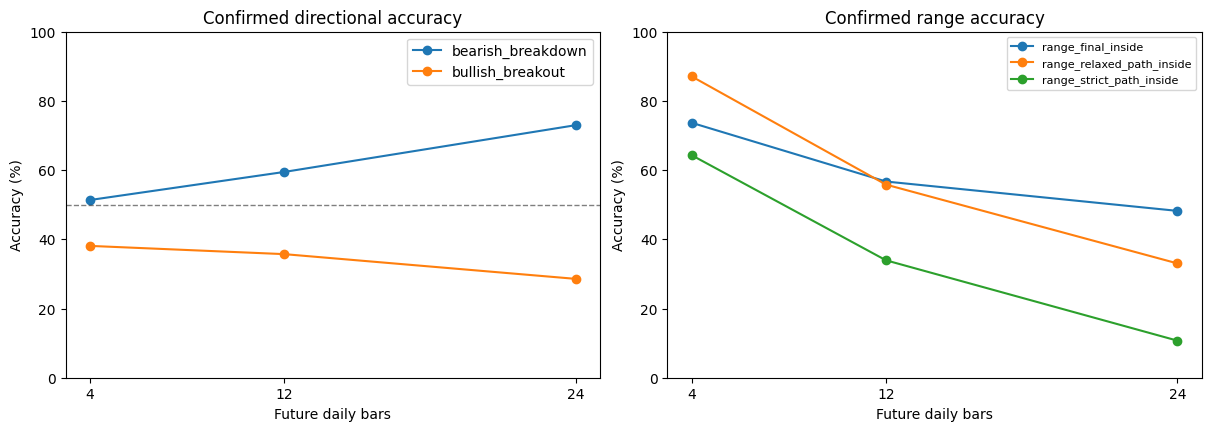

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)

for scenario, group in direction_table.groupby("scenario_id"):
    axes[0].plot(group.horizon, 100 * group.accuracy, marker="o", label=scenario)
axes[0].axhline(50, color="black", linewidth=1, linestyle="--", alpha=0.5)
axes[0].set(title="Confirmed directional accuracy", xlabel="Future daily bars", ylabel="Accuracy (%)")
axes[0].set_xticks([4, 12, 24])
axes[0].set_ylim(0, 100)
axes[0].legend()

for metric, group in range_table.groupby("metric"):
    axes[1].plot(group.horizon, 100 * group.accuracy, marker="o", label=metric)
axes[1].set(title="Confirmed range accuracy", xlabel="Future daily bars", ylabel="Accuracy (%)")
axes[1].set_xticks([4, 12, 24])
axes[1].set_ylim(0, 100)
axes[1].legend(fontsize=8)

figure_path = ROOT / "accuracy-by-horizon.png"
fig.savefig(figure_path, dpi=160)
plt.show()

### Overlap sensitivity and threshold sensitivity

Daily decisions inside a 24-day outcome window share most of their future
candles. The cooldown view retains only the first signal until its evaluation
horizon has elapsed. It is smaller but less deceptively precise.

In [8]:
cooldown_rows = []
for horizon, group in confirmed_directional.groupby("horizon", observed=True):
    sample = cooldown(group, int(horizon))
    cooldown_rows.append({
        "scenario_type": "directional",
        "horizon": horizon,
        **wilson(sample.direction_correct),
        "mean_signed_return": sample.signed_return.mean(),
    })
for horizon, group in confirmed_range.groupby("horizon", observed=True):
    sample = cooldown(group, int(horizon))
    cooldown_rows.append({
        "scenario_type": "range_final",
        "horizon": horizon,
        **wilson(sample.range_final_inside),
        "mean_signed_return": np.nan,
    })
cooldown_table = pd.DataFrame(cooldown_rows)
display(percent_table(cooldown_table))

threshold_rows = []
for horizon, group in confirmed_directional.groupby("horizon", observed=True):
    for threshold_bps in [0, 10, 30, 50]:
        threshold_rows.append({
            "horizon": horizon,
            "threshold_bps": threshold_bps,
            **wilson(group.signed_return.gt(threshold_bps / 10_000)),
        })
threshold_table = pd.DataFrame(threshold_rows)
display(percent_table(threshold_table))

,scenario_type,horizon,n,accuracy,ci_low,ci_high,mean_signed_return
0,directional,4,52,36.5,24.8,50.1,-0.002673
1,directional,12,39,48.7,33.9,63.8,0.007497
2,directional,24,31,51.6,34.8,68.0,0.015493
3,range_final,4,65,73.8,62.0,83.0,NaN
4,range_final,12,27,48.1,30.7,66.0,NaN
5,range_final,24,18,33.3,16.3,56.3,NaN


,horizon,threshold_bps,n,accuracy,ci_low,ci_high
0,4,0,79,44.3,33.9,55.3
1,4,10,79,44.3,33.9,55.3
2,4,30,79,44.3,33.9,55.3
3,4,50,79,43.0,32.7,54.0
4,12,0,79,46.8,36.2,57.7
5,12,10,79,46.8,36.2,57.7
6,12,30,79,46.8,36.2,57.7
7,12,50,79,46.8,36.2,57.7
8,24,0,79,49.4,38.6,60.2
9,24,10,79,49.4,38.6,60.2


### Does confirmation or K-line support improve accuracy?

The support verdict here includes historical price-trend, price-volume, and
relative-to-BTC families. Historical order book, taker-flow, open interest,
funding, and liquidation snapshots were unavailable and are deliberately not
simulated.

In [9]:
trigger_comparison = []
for label, sample in [
    ("triggered", df[df.trigger_met & df.direction.ne("range")]),
    ("confirmed", confirmed_directional),
]:
    for horizon, group in sample.groupby("horizon", observed=True):
        trigger_comparison.append({
            "sample": label,
            "horizon": horizon,
            **wilson(group.direction_correct),
        })
trigger_comparison = pd.DataFrame(trigger_comparison)
display(percent_table(trigger_comparison))

support_rows = []
for (direction, verdict, horizon), group in (
    df[df.confirmed]
    .groupby(["direction", "support_verdict", "horizon"], observed=True)
):
    metric = "range_final_inside" if direction == "range" else "direction_correct"
    support_rows.append({
        "direction": direction,
        "support_verdict": verdict,
        "horizon": horizon,
        "metric": metric,
        **wilson(group[metric]),
    })
support_table = pd.DataFrame(support_rows)
display(percent_table(support_table))

,sample,horizon,n,accuracy,ci_low,ci_high
0,triggered,4,118,44.1,35.4,53.1
1,triggered,12,118,43.2,34.6,52.2
2,triggered,24,118,48.3,39.5,57.2
3,confirmed,4,79,44.3,33.9,55.3
4,confirmed,12,79,46.8,36.2,57.7
5,confirmed,24,79,49.4,38.6,60.2


,direction,support_verdict,horizon,metric,n,accuracy,ci_low,ci_high
0,bearish,mixed,4,direction_correct,6,16.7,3.0,56.4
1,bearish,mixed,12,direction_correct,6,50.0,18.8,81.2
2,bearish,mixed,24,direction_correct,6,83.3,43.6,97.0
3,bearish,supports,4,direction_correct,31,58.1,40.8,73.6
4,bearish,supports,12,direction_correct,31,61.3,43.8,76.3
5,bearish,supports,24,direction_correct,31,71.0,53.4,83.9
6,bullish,mixed,4,direction_correct,4,0.0,0.0,49.0
7,bullish,mixed,12,direction_correct,4,50.0,15.0,85.0
8,bullish,mixed,24,direction_correct,4,25.0,4.6,69.9
9,bullish,supports,4,direction_correct,38,42.1,27.9,57.8


## Takeaways

1. **No validated broad directional edge yet.** Pooled confirmed-direction
   accuracy never exceeds 50% in the overlapping sample and reaches only 51.6%
   in the much smaller 24-day cooldown sample.
2. **The bearish and bullish paths must be calibrated separately.** The bearish
   branch was useful at longer horizons in this down-biased evaluation period;
   the bullish branch underperformed its base rate at every horizon.
3. **Short range classification is the strongest current use.** Four-day range
   accuracy survives the cooldown check, while medium-horizon containment
   degrades sharply.
4. **Target-touch is not forecast accuracy.** Its roughly 80% success coexists
   with sub-50% terminal direction and must be shown only as a path statistic.
5. **K-line confirmation is not a universal reliability upgrade.** It helps
   some range samples but does not improve pooled directional accuracy.
6. **Next accuracy work should be out-of-sample and versioned.** Freeze this
   rule version, add more market regimes/assets, retain historical derivatives
   and microstructure snapshots, and tune only on a training period before
   reporting a separate untouched test period.

This notebook measures descriptive historical performance, not investment
advice, a calibrated probability, or a promise of future returns.

In [10]:
def table_records(frame):
    clean = frame.replace({np.nan: None})
    return json.loads(clean.to_json(orient="records"))

summary = {
    "formulaVersion": metadata["formulaVersion"],
    "source": metadata["source"],
    "evaluationStart": metadata["evaluationStart"],
    "evaluationEnd": str(df.signal_date.max().date()),
    "assets": metadata["assets"],
    "signalAssetDays": metadata["signalDateCount"],
    "exportedRows": metadata["rowCount"],
    "rawDataSha256": metadata["rawDataSha256"],
    "recordsSha256": metadata["recordsSha256"],
    "qualityChecks": checks,
    "confirmedDirectional": table_records(direction_table),
    "pooledDirectional": table_records(pooled_direction),
    "confirmedRange": table_records(range_table),
    "cooldownSensitivity": table_records(cooldown_table),
    "thresholdSensitivity": table_records(threshold_table),
    "triggerComparison": table_records(trigger_comparison),
    "supportStratification": table_records(support_table),
    "limitations": metadata["limitations"],
}
(ROOT / "summary.json").write_text(json.dumps(summary, indent=2))
print("wrote", ROOT / "summary.json")

wrote /Users/shijie/Desktop/anything-llm/scripts/reports/crypto-market-backtest-20260728/summary.json
